# Data Preparation Pipeline

## Purpose

The `01_data_preparation.ipynb` notebook orchestrates the complete data preparation pipeline for the reinforcement learning portfolio rebalancing system. This pipeline transforms raw market data into a comprehensive, normalized feature set ready for RL agent training.

The primary goal is to:
- Acquire clean, high-quality market data from Yahoo Finance
- Engineer comprehensive features across multiple categories (momentum, volatility, volume, risk-adjusted metrics, etc.)
- Preprocess features to remove outliers, handle missing data, and reduce redundancy
- Create proper train/test splits with normalization
- Ensure no data leakage and maintain temporal integrity

## Key Objectives

1. **Data Acquisition**: Fetch weekly OHLCV data for multiple assets from Yahoo Finance
2. **Feature Engineering**: Calculate 160+ features across 8 categories using log returns
3. **Data Quality**: Handle missing data, outliers, and constant features
4. **Redundancy Reduction**: Remove highly correlated features (threshold: 0.9)
5. **Temporal Splitting**: Create chronological 80/20 train/test split
6. **Normalization**: Apply z-score scaling fitted on training data only
7. **Data Persistence**: Save processed data, scaler, and metadata for RL environment

## Prerequisites

### Required Libraries

- `pandas`, `numpy`: Data manipulation and numerical computations
- `matplotlib`, `seaborn`: Visualizations
- `scikit-learn`: Preprocessing and normalization
- `yfinance`: Yahoo Finance data fetching
- `ta`: Technical analysis indicators
- `fredapi`: FRED macroeconomic data (optional)
- `scipy`: Hierarchical clustering for correlation visualization

### System Components

- `utile.py`: Contains all utility functions for data fetching, feature engineering, and preprocessing
- `data/raw/`: Directory for raw price data and features
- `data/processed/`: Directory for preprocessed train/test splits
- `results/`: Directory for visualizations

### Data Requirements

- Internet connection for Yahoo Finance API access
- FRED API key (optional, for macroeconomic data) - see `api_keys.json`
- Date range: 2020-01-01 to 2025-01-01 (configurable)
- Minimum data: At least 1 year of weekly data for meaningful features


In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json

from sklearn.decomposition import PCA

project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))

from utile import (
    fetch_price_data, prepare_price_dataframe, fetch_macro_data,
    engineer_all_features, preprocess_pipeline, fetch_benchmark_returns
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Configuration

Define assets, date range, and directories.

**Configuration Parameters**:
- `TICKERS`: List of asset tickers to fetch (default: tech stocks)
- `START_DATE`, `END_DATE`: Date range for data acquisition
- `INTERVAL`: Data frequency ('1wk' for weekly data)
- `DATA_DIR`, `RAW_DATA_DIR`, `PROCESSED_DATA_DIR`, `RESULTS_DIR`: Directory paths

**Note**: Weekly data (`interval='1wk'`) is used to align with weekly portfolio rebalancing frequency in the RL system.


In [2]:
TICKERS = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA', 'NFLX']
START_DATE = '2020-01-01'
END_DATE = '2025-01-01'
INTERVAL = '1wk'

DATA_DIR = project_root / 'data'
RAW_DATA_DIR = DATA_DIR / 'raw'
PROCESSED_DATA_DIR = DATA_DIR / 'processed'
RESULTS_DIR = project_root / 'results'

RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


## Step 1: Fetch Price Data

Download weekly price data from Yahoo Finance.

### Methodology

**Function**: `utile.py::fetch_price_data()`

1. **Data Fetching**: Uses `yfinance` library to download OHLCV data
   - Uses `auto_adjust=False` to access both raw and adjusted prices
   - Automatically uses **Adjusted Close** prices to account for splits and dividends
   
2. **Data Conversion**: `prepare_price_dataframe()` converts multi-index DataFrame to long format
   - Extracts ticker names from column structure
   - Creates columns: `date`, `ticker`, `open`, `high`, `low`, `close`, `volume`
   - Sorts by date and ticker for consistency

3. **Data Persistence**: Saves raw price data to `data/raw/weekly_prices.parquet`

### Data Quality Checks

- Verify all tickers have data for the specified date range
- Check for missing dates or gaps in data
- Ensure Adjusted Close prices are available (handles splits/dividends automatically)

### Output

- **File**: `data/raw/weekly_prices.parquet`
- **Format**: Long format DataFrame with columns: `date`, `ticker`, `open`, `high`, `low`, `close`, `volume`
- **Frequency**: Weekly (Friday close prices)


In [3]:
price_data = fetch_price_data(
    tickers=TICKERS,
    start_date=START_DATE,
    end_date=END_DATE,
    interval=INTERVAL
)

price_df = prepare_price_dataframe(price_data)
price_df = price_df.sort_values(['date', 'ticker']).reset_index(drop=True)

price_df.to_parquet(RAW_DATA_DIR / 'weekly_prices.parquet', index=False)


### Data Overview

Visualize price data to verify quality and coverage.

**Visualizations**:
1. **Price Chart**: Weekly close prices for all tickers over time
   - Verify data coverage and identify any gaps
   - Check for outliers or data quality issues
   
2. **Returns Chart**: Weekly percentage returns
   - Verify returns are reasonable (typically -20% to +20% for weekly)
   - Identify any extreme outliers that may indicate data errors

**Interpretation**:
- Consistent price trends indicate good data quality
- Sudden jumps or drops may indicate splits (should be handled by Adjusted Close)
- Missing periods appear as gaps in the chart


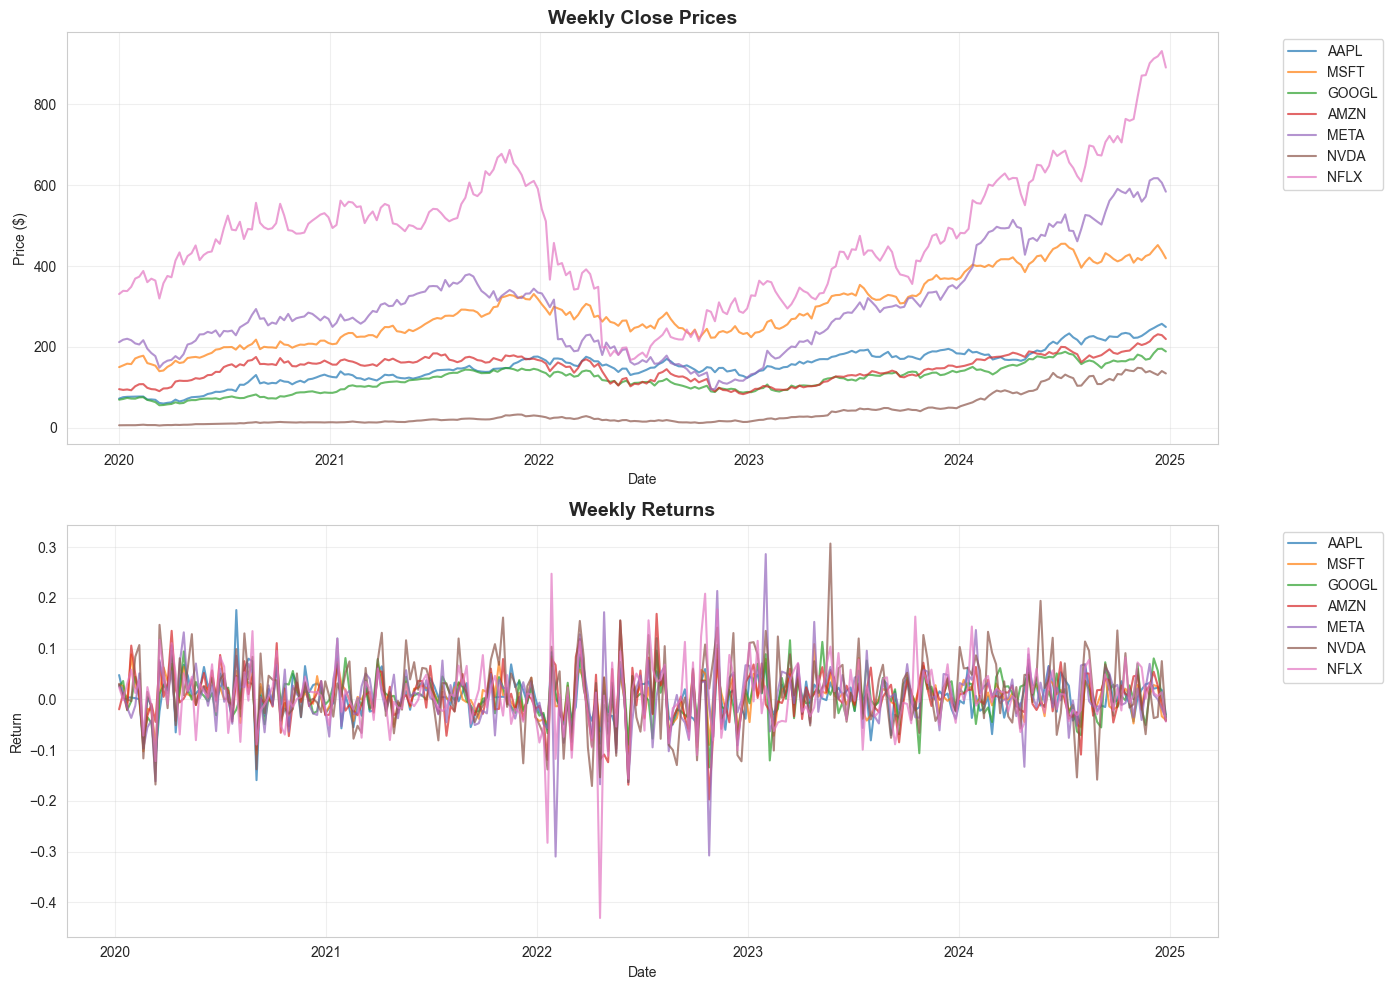

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for ticker in TICKERS:
    ticker_data = price_df[price_df['ticker'] == ticker]
    axes[0].plot(ticker_data['date'], ticker_data['close'], label=ticker, alpha=0.7)

axes[0].set_title('Weekly Close Prices', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Price ($)')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].grid(True, alpha=0.3)

for ticker in TICKERS:
    ticker_data = price_df[price_df['ticker'] == ticker]
    returns = ticker_data['close'].pct_change()
    axes[1].plot(ticker_data['date'], returns, label=ticker, alpha=0.7)

axes[1].set_title('Weekly Returns', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Return')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'price_data_overview.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 2: Feature Engineering

Calculate comprehensive features across all categories.

### Methodology

**Function**: `utile.py::engineer_all_features()`

The feature engineering process creates **~160 features** across 8 categories:

1. **Momentum & Trend Features** (~35 features)
   - Log returns: `return_1w`, `return_4w`, `return_13w`, `return_26w`
   - Technical indicators: RSI, MACD, Stochastic Oscillator, ROC
   - Price ratios: Price-to-SMA, Price-to-EMA ratios
   - Momentum indicators across multiple timeframes

2. **Volatility & Risk Features** (~20 features)
   - Annualized volatility (using log returns)
   - ATR (Average True Range)
   - Bollinger Bands (width, position)
   - Downside/upside volatility
   - Realized volatility, Parkinson volatility

3. **Volume & Liquidity Features** (~30 features)
   - OBV (On-Balance Volume) and its rate of change
   - Relative volume ratios
   - VWAP distance and momentum (using log returns)
   - Volume-price divergence and correlation
   - MFI (Money Flow Index), Chaikin Money Flow

4. **Risk-Adjusted Performance Features** (~15 features)
   - Sharpe, Sortino, Calmar ratios (using log returns)
   - Correlation to QQQ benchmark
   - Beta to market
   - Relative returns

5. **Drawdown & Path Risk Features** (~25 features)
   - Current drawdown, drawdown duration
   - Maximum drawdown over rolling windows
   - Recovery factors, Ulcer Index, Pain Index
   - MAE (Maximum Adverse Excursion), MFE (Maximum Favorable Excursion)

6. **Statistical Features** (6 features)
   - Skewness and kurtosis of log returns
   - Autocorrelation at lag 1 and 4

7. **Calendar Features** (6 features)
   - Cyclical encodings: `sin_month`, `cos_month`, `sin_dow`, `cos_dow`, `sin_dom`, `cos_dom`
   - Note: `sin_dow`, `cos_dow` may be constant for weekly data and will be removed

8. **Macroeconomic Features** (5 features, if available)
   - Treasury 10Y yield, Fed Funds Rate, VIX, Unemployment Rate, GDP Growth

### Key Implementation Details

**Log Returns**: All price-based returns use log returns (`ln(P_t / P_{t-n})`) instead of simple percentage returns. This provides:
- Time-additive property for multi-period calculations
- Better statistical properties for financial modeling
- Standard practice in quantitative finance

**Benchmark Data**: Fetches QQQ (Nasdaq-100 ETF) returns for risk-adjusted features and market correlation.

**Macro Data**: Fetches from FRED API if available. Uses forward-fill strategy to handle sparse updates.

**Per-Ticker Calculation**: All features are calculated per-ticker to maintain asset-specific characteristics.

### Output

- **File**: `data/raw/features_raw.parquet`
- **Features**: ~160 feature columns plus `date`, `ticker`, and OHLCV columns
- **Missing Data**: Some features may have NaN values due to rolling window requirements


In [5]:
# Fetch benchmark returns using the helper function
benchmark_returns = fetch_benchmark_returns(
    ticker='QQQ',
    start_date=START_DATE,
    end_date=END_DATE,
    interval=INTERVAL
)

# Fetch macroeconomic data from FRED
macro_data = fetch_macro_data(
    start_date=START_DATE,
    end_date=END_DATE
)

features_df = engineer_all_features(
    price_df, 
    benchmark_returns=benchmark_returns,
    macro_data=macro_data
)

feature_cols = [col for col in features_df.columns 
                if col not in ['date', 'ticker', 'open', 'high', 'low', 'close', 'volume']]

features_df.to_parquet(RAW_DATA_DIR / 'features_raw.parquet', index=False)

features_df


,date,open,high,low,close,volume,ticker,treasury_10y,fed_funds_rate,vix,...,skew_13w,skew_26w,kurt_13w,kurt_26w,autocorr_1w,autocorr_4w,sin_month,cos_month,sin_dom,cos_dom
0,2020-01-01,74.059998,75.224998,73.187500,71.995338,509062400,AAPL,1.87,1.55,13.45,...,NaN,NaN,NaN,NaN,NaN,NaN,5.000000e-01,0.866025,0.201299,0.979530
1,2020-01-01,93.750000,95.694504,93.000000,95.343002,318002000,AMZN,1.87,1.55,13.45,...,NaN,NaN,NaN,NaN,NaN,NaN,5.000000e-01,0.866025,0.201299,0.979530
2,2020-01-01,67.420502,70.175003,67.324501,69.277687,131784000,GOOGL,1.87,1.55,13.45,...,NaN,NaN,NaN,NaN,NaN,NaN,5.000000e-01,0.866025,0.201299,0.979530
3,2020-01-01,206.750000,214.580002,206.270004,211.754578,55236800,META,1.87,1.55,13.45,...,NaN,NaN,NaN,NaN,NaN,NaN,5.000000e-01,0.866025,0.201299,0.979530
4,2020-01-01,158.779999,160.729996,156.509995,149.899277,86186100,MSFT,1.87,1.55,13.45,...,NaN,NaN,NaN,NaN,NaN,NaN,5.000000e-01,0.866025,0.201299,0.979530
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1822,2024-12-25,195.149994,196.750000,188.509995,188.684860,62669600,GOOGL,4.50,5.33,27.62,...,0.402662,0.073227,-0.437822,-0.603853,0.140646,0.124975,-2.449294e-16,1.000000,-0.937752,0.347305
1823,2024-12-25,605.479980,606.299988,583.849976,584.145508,27211000,META,4.50,5.33,27.62,...,0.453025,-0.065834,0.172585,-0.433922,-0.075353,-0.464016,-2.449294e-16,1.000000,-0.937752,0.347305
1824,2024-12-25,439.079987,440.940002,420.660004,419.196564,52717100,MSFT,4.50,5.33,27.62,...,-0.733891,-0.202923,-0.962708,-0.858664,-0.068857,0.146567,-2.449294e-16,1.000000,-0.937752,0.347305
1825,2024-12-25,928.400024,930.489990,889.469971,891.320007,9645400,NFLX,4.50,5.33,27.62,...,0.274352,0.453966,-0.243494,-0.768218,-0.218356,-0.004175,-2.449294e-16,1.000000,-0.937752,0.347305


## Step 3: Data Preprocessing

Apply preprocessing pipeline: outlier removal, correlation filtering, split, normalization.

### Preprocessing Pipeline Overview

**Function**: `utile.py::preprocess_pipeline()`

The preprocessing pipeline consists of 6 sequential steps:

1. **Constant Feature Removal** (Step 0)
   - Removes features with zero or near-zero variance
   - Criteria: `nunique() <= 1` or `std() < 1e-8`
   - Example: `sin_dow`, `cos_dow` for weekly data (constant value)

2. **Missing Data Handling** (Step 1)
   - Row filtering: Drop rows with >50% missing features (notebook-level)
   - Feature filling: Fill remaining NaN with 0 (pipeline-level)
   - Rationale: Balance data retention with quality

3. **Outlier Removal** (Step 2)
   - Clips extreme values at 1st and 99th percentiles
   - Prevents outliers from dominating feature scaling
   - Maintains 98% of data while removing extreme outliers

4. **Correlation Filtering** (Step 3)
   - Removes features with correlation > 0.9 (absolute value)
   - For correlated pairs, removes feature with lower variance
   - Reduces features from ~160 to ~110
   - Rationale: Highly correlated features provide redundant information

5. **Train/Test Split** (Step 5)
   - Chronological 80/20 split based on date
   - No random shuffling to maintain temporal order
   - Test set reserved for final evaluation only

6. **Normalization** (Step 6)
   - Z-score scaling: `z = (x - μ) / σ`
   - Scaler fitted on training data only (prevents data leakage)
   - Test data transformed using training statistics
   - Ensures training set has mean ≈ 0, std ≈ 1

### Preprocessing Parameters

- `train_ratio=0.8`: 80% training, 20% testing
- `clip_percentiles=(0.01, 0.99)`: Clip outliers at 1st and 99th percentiles
- `corr_threshold=0.9`: Remove features with |correlation| > 0.9
- `use_pca=False`: PCA disabled (not needed for ~160 features)

### Data Leakage Prevention

**Critical Rules**:
1. **Chronological Split**: Test dates must be after train dates
2. **Scaler Fitting**: Fit scaler on training data only, never on test data
3. **Rolling Windows**: All rolling calculations use only past data
4. **Calmar Ratio**: Uses `max_dd.rolling(period).min()` instead of global minimum


In [6]:
# Check data before cleaning
print(f"Rows before cleaning: {len(features_df)}")
print(f"Feature columns: {len(feature_cols)}")

# Check missing data pattern
missing_counts = features_df[feature_cols].isna().sum()
high_missing_features = missing_counts[missing_counts / len(features_df) > 0.5]
if len(high_missing_features) > 0:
    print(f"Features with >50% missing: {len(high_missing_features)}")
    print(high_missing_features.head(10))

# Drop rows only if more than 50% of features are missing (less aggressive)
row_missing_pct = features_df[feature_cols].isna().sum(axis=1) / len(feature_cols)
features_df_clean = features_df[row_missing_pct <= 0.5].copy()
print(f"Rows after cleaning (dropped rows with >50% missing features): {len(features_df_clean)}")

if len(features_df_clean) == 0:
    raise ValueError("All rows dropped after cleaning. Check for features with too many missing values.")

preprocessed = preprocess_pipeline(
    df=features_df_clean,
    feature_cols=feature_cols,
    train_ratio=0.8,
    clip_percentiles=(0.01, 0.99),
    corr_threshold=0.95,
    date_col='date'
)

train_df = preprocessed['train']
test_df = preprocessed['test']
scaler = preprocessed['scaler']
removed_features = preprocessed['removed_features']


Rows before cleaning: 1827
Feature columns: 158
Rows after cleaning (dropped rows with >50% missing features): 1736


### Preprocessing Summary

Display statistics about preprocessing steps.

**Summary Metrics**:
- **Original Features**: Number of features before preprocessing (~160)
- **Removed (High Correlation)**: Features removed due to high correlation
- **Final Features**: Number of features after preprocessing (~110)
- **Train Samples**: Number of training samples
- **Test Samples**: Number of test samples
- **Train Dates**: Number of unique dates in training set
- **Test Dates**: Number of unique dates in test set

**Interpretation**:
- Feature reduction: ~30% reduction (160 → 110) indicates good redundancy removal
- Sample counts: Should have sufficient data for training (typically >1000 samples)
- Date coverage: Verify train/test dates don't overlap (data leakage check)


In [7]:
# Get final feature columns (excluding metadata columns)
print("Computing correlation matrix...")
train_feature_cols = [col for col in train_df.columns 
                      if col not in ['date', 'ticker', 'open', 'high', 'low', 'close', 'volume']]

# Calculate correlation matrix using training data
corr_data = train_df[train_feature_cols].fillna(0)
corr_matrix = corr_data.corr()

print(f"\n✓ Correlation matrix shape: {corr_matrix.shape}")

# Find highly correlated feature pairs (|correlation| > 0.95)
# Threshold 0.95 chosen to balance redundancy removal with information preservation:
# - Lower (e.g., 0.90) would remove more features but risk losing complementary info
# - Higher (e.g., 0.98) would be too conservative and miss obvious redundancies
# Using absolute value to catch both positive and negative high correlations
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.95:  # Threshold: 0.95
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_val
            ))

print(f"\n📊 Highly Correlated Feature Pairs (|r| > 0.95): {len(high_corr_pairs)}")

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs, columns=['Feature 1', 'Feature 2', 'Correlation'])
    print(high_corr_df.head(20))


Computing correlation matrix...

✓ Correlation matrix shape: (125, 125)

📊 Highly Correlated Feature Pairs (|r| > 0.95): 1
    Feature 1    Feature 2  Correlation
0  sharpe_52w  sortino_52w     0.956722


In [8]:
# Identify redundant features using correlation
# For each highly correlated pair, keep the feature with higher variance
# Rationale: Higher variance features contain more information, so we prefer
# to keep them over lower variance features that provide redundant information
features_to_remove_corr = set()

for feat1, feat2, corr_val in high_corr_pairs:
    var1 = train_df[feat1].var()
    var2 = train_df[feat2].var()
    
    # Remove the feature with lower variance (keeps more informative feature)
    if var1 < var2:
        features_to_remove_corr.add(feat1)
    else:
        features_to_remove_corr.add(feat2)

print(f"\n📊 Features to remove due to high correlation: {len(features_to_remove_corr)}")
print(f"Remaining features after correlation removal: {len(feature_cols) - len(features_to_remove_corr)}")

if features_to_remove_corr:
    print("\nFeatures to remove:")
    for feat in sorted(features_to_remove_corr):
        print(f"  - {feat}")

# Keep features that are not highly correlated
features_after_corr = [f for f in feature_cols if f not in features_to_remove_corr]



📊 Features to remove due to high correlation: 1
Remaining features after correlation removal: 157

Features to remove:
  - sortino_52w


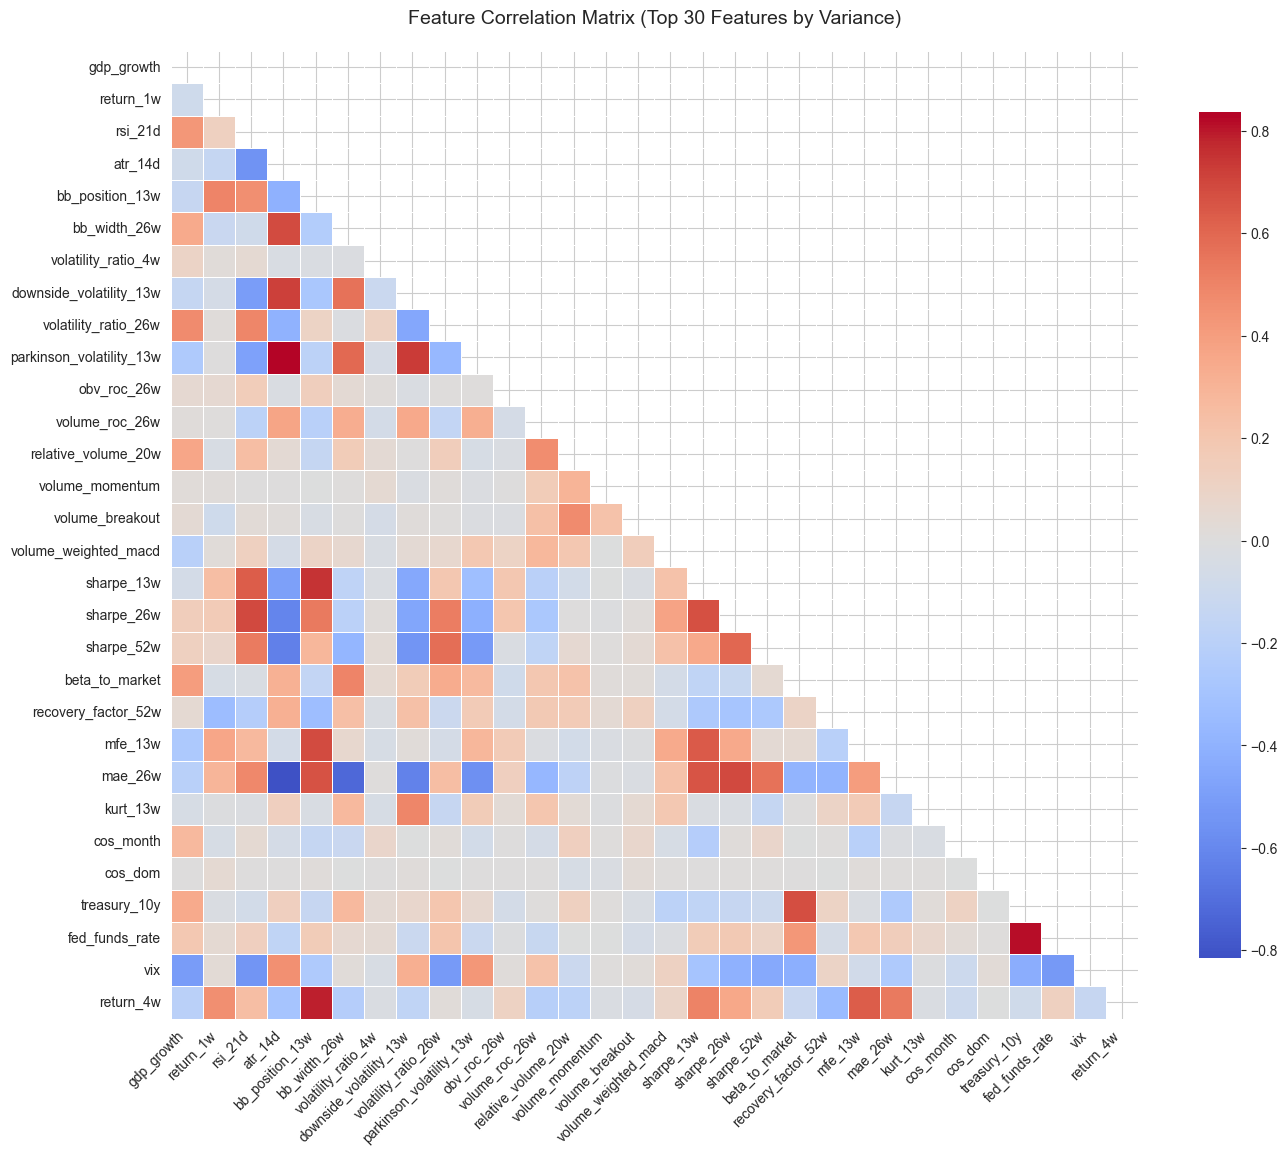

In [9]:

# Select top 30 features by variance for sample visualization
top_features = train_df[train_feature_cols].var().nlargest(30).index.tolist()
corr_sample = corr_matrix.loc[top_features, top_features]

# Create visualization of top 30 features by variance
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_sample, dtype=bool))
sns.heatmap(corr_sample, mask=mask, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, fmt='.2f')
plt.title('Feature Correlation Matrix (Top 30 Features by Variance)', fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## 4. Principal Component Analysis (PCA)

### Purpose

Determine the intrinsic dimensionality of the feature space and identify redundant dimensions. PCA transforms features into orthogonal components that capture maximum variance.

### Methodology

1. **Data Preparation**: 
   - Remove highly correlated features (from previous step)
   - Remove zero-variance features
   - Standardize features (mean=0, std=1) to ensure equal scaling

2. **PCA Computation**: Fit PCA on all components to analyze explained variance

3. **Variance Analysis**: Calculate cumulative explained variance to determine:
   - Number of components for 90% variance (captures most information)
   - Number of components for 95% variance (high information retention)
   - Number of components for 99% variance (near-complete information)

### Variance Threshold Interpretation

- **90% variance**: Good balance between dimensionality reduction and information retention
- **95% variance**: Conservative reduction, retains most information
- **99% variance**: Minimal reduction, captures nearly all information

### Component Analysis

Each principal component is a linear combination of original features. The loadings show which features contribute most to each component:
- High positive/negative loadings indicate strong contribution
- Components are ordered by explained variance (first component explains most variance)

### Use Case

While PCA identifies dimensionality, we don't use PCA-transformed features directly. Instead, we use PCA insights to inform feature selection, ensuring we keep features that contribute to high-variance components.


In [10]:
# Prepare data for PCA
# Filter features_after_corr to only include features that exist in train_df
# Some features may have been removed during preprocessing
non_feature_cols = ['date', 'ticker', 'open', 'high', 'low', 'close', 'volume']
available_features = [col for col in train_df.columns if col not in non_feature_cols]
features_for_pca = [f for f in features_after_corr if f in available_features]
X_pca = train_df[features_for_pca].fillna(0)

# Remove features with zero variance
# Zero variance features provide no information and cause numerical issues in PCA
zero_var_features = X_pca.columns[X_pca.var() == 0]
features_for_pca = [f for f in features_for_pca if f not in zero_var_features]
X_pca = train_df[features_for_pca].fillna(0)

# Run PCA on all components
# We fit on all components to analyze the full variance structure
print(f"Running PCA on {len(features_for_pca)} features...")
pca = PCA()
pca.fit(X_pca)

# Calculate cumulative explained variance
# This tells us how much variance is captured by the first N components
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Find number of components for 90%, 95%, 99% variance thresholds
# These thresholds help understand the intrinsic dimensionality:
# - 90%: Good balance between reduction and information retention
# - 95%: Conservative reduction, retains most information
# - 99%: Near-complete information capture
n_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_95 = np.argmax(cumulative_variance >= 0.95) + 1
n_99 = np.argmax(cumulative_variance >= 0.99) + 1

print(f"\n📊 PCA Results:")
print(f"  Components for 90% variance: {n_90}")
print(f"  Components for 95% variance: {n_95}")
print(f"  Components for 99% variance: {n_99}")
print(f"  Total components: {len(pca.components_)}")

Running PCA on 124 features...

📊 PCA Results:
  Components for 90% variance: 34
  Components for 95% variance: 48
  Components for 99% variance: 77
  Total components: 124


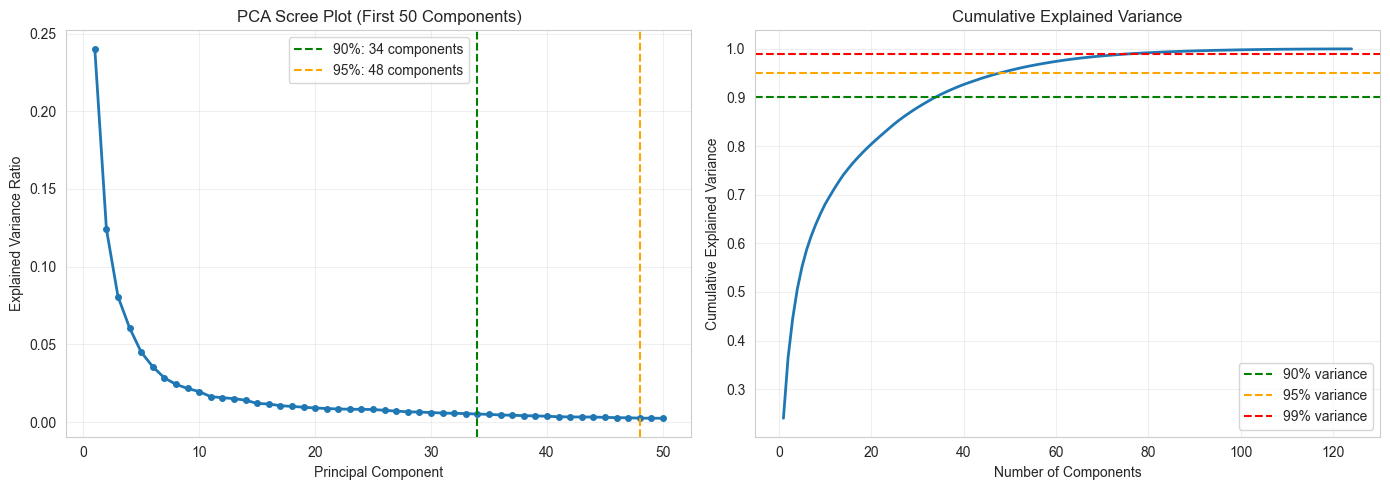

In [11]:
# Plot explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
n_components_show = min(50, len(pca.explained_variance_ratio_))
axes[0].plot(range(1, n_components_show + 1),
             pca.explained_variance_ratio_[:n_components_show], 'o-', linewidth=2, markersize=4)
axes[0].axvline(x=n_90, color='green', linestyle='--', label=f'90%: {n_90} components')
axes[0].axvline(x=n_95, color='orange', linestyle='--', label=f'95%: {n_95} components')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('PCA Scree Plot (First 50 Components)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Cumulative variance plot
axes[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, linewidth=2)
axes[1].axhline(y=0.90, color='green', linestyle='--', label='90% variance')
axes[1].axhline(y=0.95, color='orange', linestyle='--', label='95% variance')
axes[1].axhline(y=0.99, color='red', linestyle='--', label='99% variance')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [12]:
# Analyze feature loadings for top components
# Get top 10 components
n_top_components = min(10, len(pca.components_))

print(f"\n📊 Top {n_top_components} Principal Components:")
print("=" * 80)

for i in range(n_top_components):
    explained_var = pca.explained_variance_ratio_[i]
    component = pca.components_[i]
    
    # Get top 10 features contributing to this component
    top_indices = np.argsort(np.abs(component))[-10:][::-1]
    top_features = [features_for_pca[idx] for idx in top_indices]
    top_loadings = component[top_indices]
    
    print(f"\nComponent {i+1} (Explained Variance: {explained_var:.2%}):")
    for feat, loading in zip(top_features, top_loadings):
        print(f"  {feat:30s}: {loading:7.4f}")



📊 Top 10 Principal Components:

Component 1 (Explained Variance: 24.02%):
  mae_26w                       :  0.1694
  rsi_14d                       :  0.1681
  mae_13w                       :  0.1660
  rsi_7d                        :  0.1587
  return_13w                    :  0.1498
  stochastic_21w                :  0.1483
  atr_14d                       : -0.1481
  bb_position                   :  0.1478
  sharpe_13w                    :  0.1455
  stochastic_14w                :  0.1449

Component 2 (Explained Variance: 12.43%):
  upside_volatility_26w         :  0.1935
  max_drawdown_26w              : -0.1934
  volatility_26w                :  0.1838
  max_drawdown_52w              : -0.1819
  parkinson_volatility_26w      :  0.1812
  avg_drawdown_52w              : -0.1771
  mfe_26w                       :  0.1753
  volatility_52w                :  0.1747
  bb_width_26w                  :  0.1639
  drawdown_volatility_52w       :  0.1589

Component 3 (Explained Variance: 8.07%):


In [13]:
# Prepare target variable: future returns (1-week ahead)
# For each ticker, calculate next week's return
# Sorting ensures proper time ordering before shifting
train_data_sorted = train_df.sort_values(['ticker', 'date']).copy()

# Calculate forward returns from close prices (log returns)
# Note: log_returns column is not available in featured_data after engineering,
# so we calculate it directly from close prices
# Log returns: log(P_t+1 / P_t) = log(P_t+1) - log(P_t)
# Groupby('ticker') ensures we shift within each ticker's time series
train_data_sorted['next_close'] = train_data_sorted.groupby('ticker')['close'].shift(-1)
train_data_sorted['future_return'] = np.log(train_data_sorted['next_close'] / train_data_sorted['close'])
train_data_sorted = train_data_sorted.drop(columns=['next_close'])

# Remove rows with missing future returns
# Last week for each ticker will have NaN future_return (no next week available)
train_data_clean = train_data_sorted.dropna(subset=['future_return']).copy()

# Prepare features and target for SHAP analysis
# Use features after correlation removal and PCA preparation
X_shap = train_data_clean[features_for_pca].fillna(0)
y_shap = train_data_clean['future_return']

print(f"\n📊 SHAP Analysis Setup:")
print(f"  Features: {X_shap.shape[1]}")
print(f"  Samples: {X_shap.shape[0]}")
print(f"  Target: Future 1-week return")



📊 SHAP Analysis Setup:
  Features: 124
  Samples: 1379
  Target: Future 1-week return


In [14]:
# Train a Random Forest model as surrogate for SHAP
# Random Forest chosen because:
# 1. Handles non-linear relationships well
# 2. Works efficiently with SHAP TreeExplainer
# 3. Provides feature importance as fallback if SHAP unavailable
# Use a sample for faster computation (SHAP is computationally expensive)
from sklearn.ensemble import RandomForestRegressor
sample_size = len(X_shap)
sample_indices = np.random.choice(len(X_shap), sample_size, replace=False)
X_sample = X_shap.iloc[sample_indices]
y_sample = y_shap.iloc[sample_indices]

print(f"\nTraining Random Forest on {sample_size} samples...")
rf_model = RandomForestRegressor(
    n_estimators=500,        # Number of trees (more = better but slower)
    max_depth=10,             # Limit tree depth to prevent overfitting
    min_samples_split=20,    # Minimum samples to split (prevents overfitting)
    random_state=42,         # For reproducibility
    n_jobs=-1                # Use all CPU cores
)

rf_model.fit(X_sample, y_sample)
print(f"✓ Model trained. R² score: {rf_model.score(X_sample, y_sample):.4f}")



Training Random Forest on 1379 samples...
✓ Model trained. R² score: 0.4601


In [15]:
# Calculate SHAP values (if available)
import shap
# Use a smaller sample for SHAP computation (it's computationally expensive)
# SHAP complexity: O(n_samples × n_features × n_trees)
# Using 500 samples balances accuracy with computation time
shap_sample_size = len(X_sample)
shap_indices = np.random.choice(len(X_sample), shap_sample_size, replace=False)
X_shap_sample = X_sample.iloc[shap_indices]

print(f"\nComputing SHAP values for {shap_sample_size} samples...")
print("This may take a few minutes...")

# Create SHAP explainer using TreeExplainer (optimized for tree models)
# TreeExplainer is faster than KernelExplainer for tree-based models
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_shap_sample)

print("✓ SHAP values computed")

# Calculate mean absolute SHAP values for feature importance ranking
mean_abs_shap = np.abs(shap_values).mean(axis=0)

# Create feature importance dataframe
shap_importance = pd.DataFrame({
    'feature': features_for_pca,
    'mean_abs_shap': mean_abs_shap,
    'rank': range(1, len(features_for_pca) + 1)
}).sort_values('mean_abs_shap', ascending=False)

shap_importance['rank'] = range(1, len(shap_importance) + 1)

print("\n📊 Top 30 Features by SHAP Importance:")
print("=" * 80)
print(shap_importance.head(30).to_string(index=False))

rf_importance = pd.DataFrame({
    'feature': features_for_pca,
    'importance': rf_model.feature_importances_,
    'rank': range(1, len(features_for_pca) + 1)
}).sort_values('importance', ascending=False)

rf_importance['rank'] = range(1, len(rf_importance) + 1)
shap_importance = rf_importance.rename(columns={'importance': 'mean_abs_shap'})

print("\n📊 Top 30 Features by Random Forest Importance:")
print("=" * 80)
print(shap_importance.head(30).to_string(index=False))



Computing SHAP values for 1379 samples...
This may take a few minutes...
✓ SHAP values computed

📊 Top 30 Features by SHAP Importance:
               feature  mean_abs_shap  rank
            obv_roc_1w       0.003333     1
 volume_trend_strength       0.001530     2
          treasury_10y       0.000872     3
                   vix       0.000845     4
downside_volatility_4w       0.000779     5
          momentum_26w       0.000774     6
            vwap_trend       0.000712     7
                rsi_7d       0.000702     8
          momentum_13w       0.000696     9
drawdown_volatility_4w       0.000694    10
                  macd       0.000689    11
      price_to_sma_20w       0.000669    12
         vwap_momentum       0.000626    13
               mae_26w       0.000539    14
           autocorr_1w       0.000529    15
      current_drawdown       0.000528    16
      avg_drawdown_52w       0.000465    17
 upside_volatility_13w       0.000463    18
        stochastic_21w      

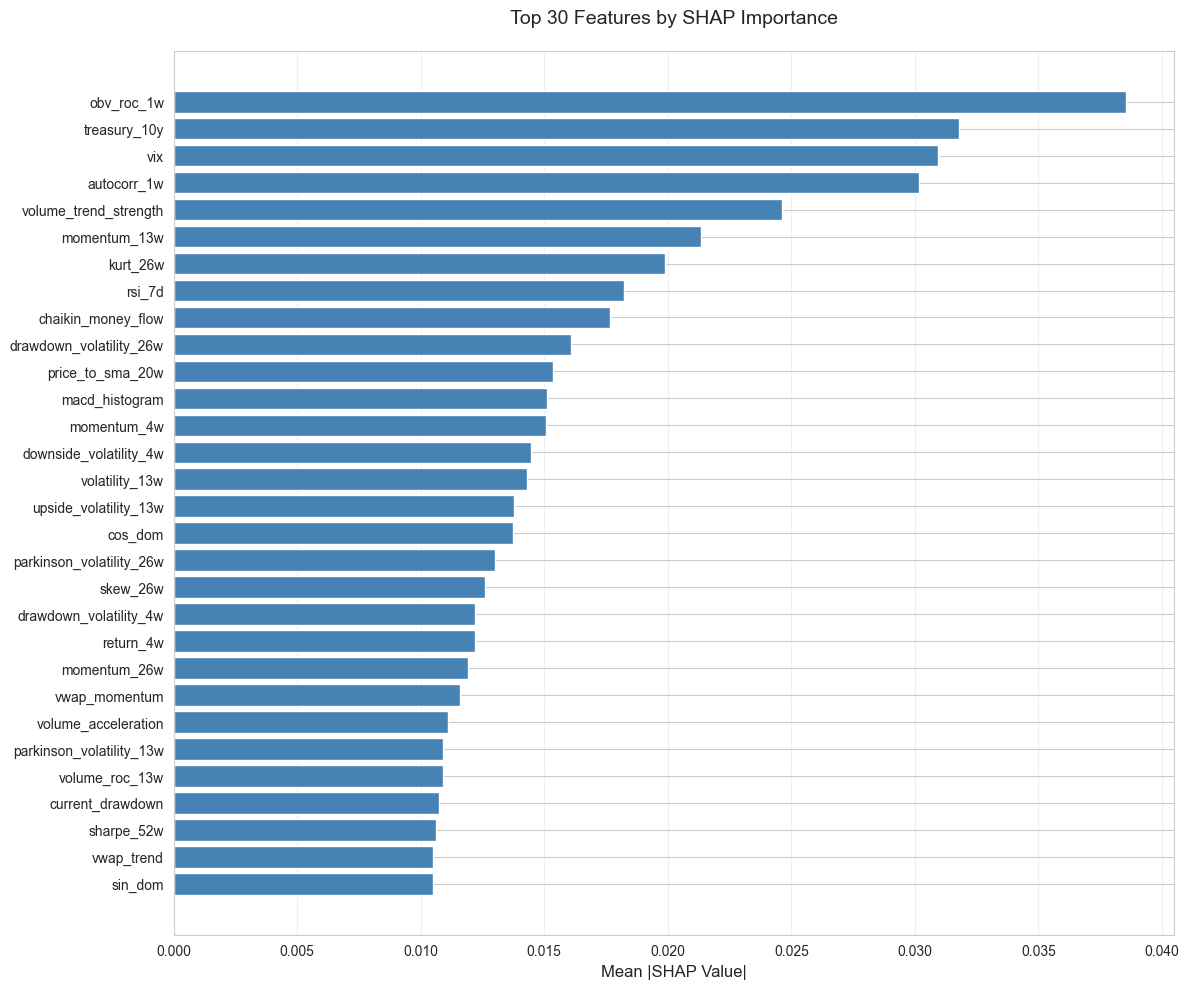

In [16]:
# Visualize feature importance
plt.figure(figsize=(12, 10))
top_n = 30
top_shap = shap_importance.head(top_n)
SHAP_AVAILABLE = True

plt.barh(range(len(top_shap)), top_shap['mean_abs_shap'], color='steelblue')
plt.yticks(range(len(top_shap)), top_shap['feature'])
plt.xlabel('Mean |SHAP Value|' if SHAP_AVAILABLE else 'Feature Importance', fontsize=12)
plt.title(f'Top {top_n} Features by {"SHAP" if SHAP_AVAILABLE else "Random Forest"} Importance', fontsize=14, pad=20)
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()


In [17]:
# Combine all methods to select 30-40 core features
# Strategy:
# 1. Remove highly correlated features (already done in correlation analysis)
# 2. Keep top features by SHAP/RF importance (from SHAP analysis)
# 3. Ensure diversity across feature categories (prevents over-reliance on one type)

# Target: 30-40 features balances information content with model complexity
# - Too few (<20): May miss important predictive signals
# - Too many (>50): Increases overfitting risk, slows training, adds noise
target_n_features = 100  # Target 30-40 features

# Start with top SHAP features
top_shap_features = shap_importance.head(target_n_features)['feature'].tolist()

print(f"\n📊 Feature Selection Strategy:")
print(f"  Target: {target_n_features} features")
print(f"  Top importance features: {len(top_shap_features)}")

# Categorize features to ensure diversity
# feature_categories = {
#     'returns': [f for f in top_shap_features if 'returns' in f.lower() or 'return' in f.lower()],
#     'volatility': [f for f in top_shap_features if 'volatility' in f.lower() or 'vol' in f.lower()],
#     'sma': [f for f in top_shap_features if 'sma' in f.lower()],
#     'price_ratios': [f for f in top_shap_features if 'price_to_sma' in f.lower() or 'ratio' in f.lower()],
#     'volume': [f for f in top_shap_features if 'volume' in f.lower()],
#     'technical': [f for f in top_shap_features if any(x in f.lower() for x in ['rsi', 'macd', 'bb', 'atr'])],
#     'sharpe': [f for f in top_shap_features if 'sharpe' in f.lower()],
#     'regime': [f for f in top_shap_features if any(x in f.lower() for x in ['regime', 'trend', 'beta'])],
#     'relative': [f for f in top_shap_features if 'relative' in f.lower() or 'rank' in f.lower()],
#     'other': []
# }

# Add remaining features to 'other'
# all_categorized = sum(feature_categories.values(), [])
# feature_categories['other'] = [f for f in top_shap_features if f not in all_categorized]

# print("\n📊 Feature Distribution by Category:")
# for category, features in feature_categories.items():
#     if features:
#         print(f"  {category:15s}: {len(features):2d} features")
#         for feat in features[:5]:  # Show first 5
#             print(f"    - {feat}")
#         if len(features) > 5:
#             print(f"    ... and {len(features) - 5} more")



📊 Feature Selection Strategy:
  Target: 100 features
  Top importance features: 100


In [18]:
# Final feature selection: ensure we have diverse representation
# If we have fewer than target, add more from importance ranking
selected_features = top_shap_features.copy()

if len(selected_features) < target_n_features:
    # Add more features from importance ranking
    remaining_features = shap_importance[~shap_importance['feature'].isin(selected_features)]
    n_needed = target_n_features - len(selected_features)
    selected_features.extend(remaining_features.head(n_needed)['feature'].tolist())

# Ensure we don't exceed target
selected_features = selected_features[:target_n_features]

print(f"\n✓ Final Selected Features: {len(selected_features)}")
print("\nSelected Features:")
for i, feat in enumerate(selected_features, 1):
    importance_val = shap_importance[shap_importance['feature'] == feat]['mean_abs_shap'].values[0]
    print(f"  {i:2d}. {feat:35s} ({'SHAP' if SHAP_AVAILABLE else 'RF'}: {importance_val:.6f})")



✓ Final Selected Features: 100

Selected Features:
   1. obv_roc_1w                          (SHAP: 0.038555)
   2. treasury_10y                        (SHAP: 0.031799)
   3. vix                                 (SHAP: 0.030922)
   4. autocorr_1w                         (SHAP: 0.030177)
   5. volume_trend_strength               (SHAP: 0.024643)
   6. momentum_13w                        (SHAP: 0.021353)
   7. kurt_26w                            (SHAP: 0.019875)
   8. rsi_7d                              (SHAP: 0.018210)
   9. chaikin_money_flow                  (SHAP: 0.017672)
  10. drawdown_volatility_26w             (SHAP: 0.016075)
  11. price_to_sma_20w                    (SHAP: 0.015354)
  12. macd_histogram                      (SHAP: 0.015095)
  13. momentum_4w                         (SHAP: 0.015090)
  14. downside_volatility_4w              (SHAP: 0.014465)
  15. volatility_13w                      (SHAP: 0.014293)
  16. upside_volatility_13w               (SHAP: 0.013776)
  17

In [19]:
# Verify selected features don't have high correlation
selected_corr = train_df[selected_features].corr()
thr = 0.98
# Count high correlations in selected set
high_corr_count = 0
for i in range(len(selected_corr.columns)):
    for j in range(i+1, len(selected_corr.columns)):
        if abs(selected_corr.iloc[i, j]) > thr:
            high_corr_count += 1

print(f"\n📊 Selected Features Validation:")
print(f"  Total features: {len(selected_features)}")
print(f"  High correlations (|r| > {thr}): {high_corr_count}")
print(f"  Average correlation: {selected_corr.values[np.triu_indices_from(selected_corr.values, k=1)].mean():.4f}")

if high_corr_count > 0:
    print("\n⚠️ Warning: Some selected features are highly correlated")
else:
    print("\n✓ Good: No highly correlated features in selected set")



📊 Selected Features Validation:
  Total features: 100
  High correlations (|r| > 0.98): 0
  Average correlation: 0.0784

✓ Good: No highly correlated features in selected set


In [20]:
final_feature_cols = selected_features.copy()

summary = {
    'Original Features': len(feature_cols),
    'Removed (High Correlation)': len(removed_features),
    'Removed (SHAP Importance)': len(feature_cols) - len(final_feature_cols) - len(removed_features),
    'Final Features': len(final_feature_cols),
    'Train Samples': len(train_df),
    'Test Samples': len(test_df),
    'Train Dates': train_df['date'].nunique(),
    'Test Dates': test_df['date'].nunique()
}

summary_df = pd.DataFrame([summary]).T
summary_df.columns = ['Value']
print(summary_df.to_string())

                            Value
Original Features             158
Removed (High Correlation)     33
Removed (SHAP Importance)      25
Final Features                100
Train Samples                1386
Test Samples                  350
Train Dates                   198
Test Dates                     50


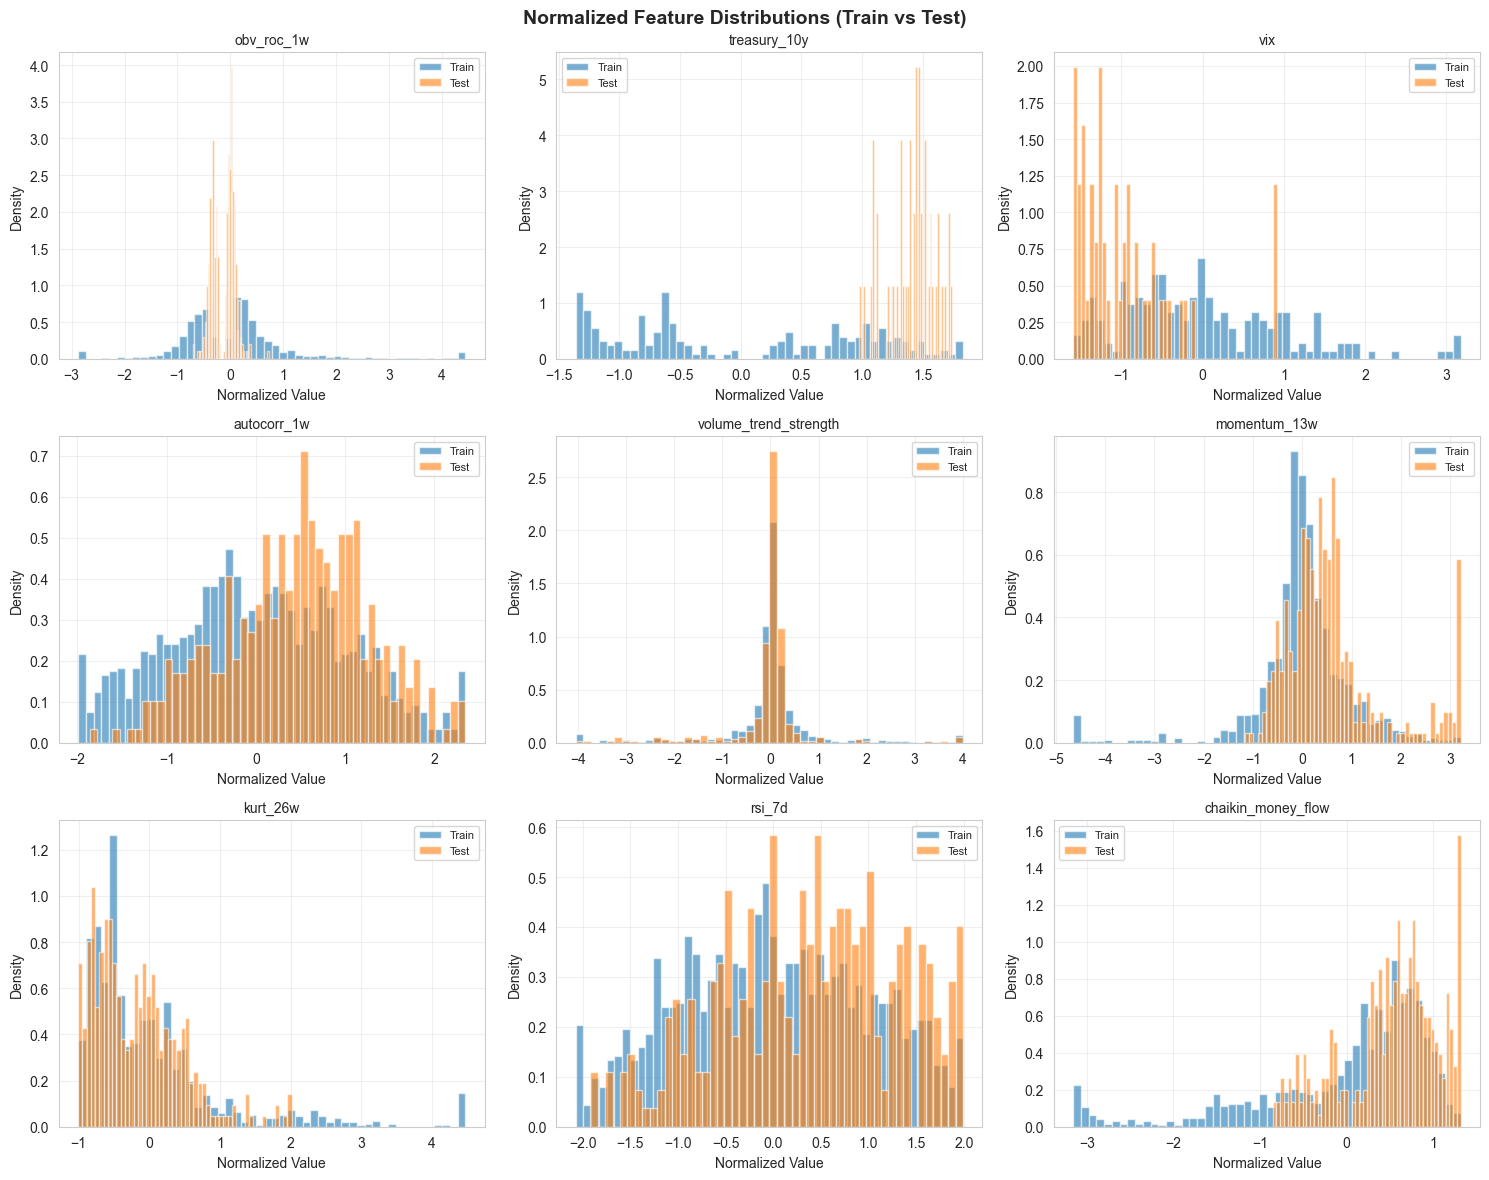

In [21]:
sample_features = final_feature_cols[:9]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for idx, feat in enumerate(sample_features):
    if feat in train_df.columns:
        train_vals = train_df[feat].dropna()
        test_vals = test_df[feat].dropna()
        
        axes[idx].hist(train_vals, bins=50, alpha=0.6, label='Train', density=True)
        axes[idx].hist(test_vals, bins=50, alpha=0.6, label='Test', density=True)
        axes[idx].set_title(feat, fontsize=10)
        axes[idx].set_xlabel('Normalized Value')
        axes[idx].set_ylabel('Density')
        axes[idx].legend(fontsize=8)
        axes[idx].grid(True, alpha=0.3)

plt.suptitle('Normalized Feature Distributions (Train vs Test)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 4: Save Processed Data

Save preprocessed datasets and metadata for RL environment and training.

### Output Files

1. **`data/processed/train.parquet`**
   - Preprocessed training data (80% of data)
   - Normalized features (mean ≈ 0, std ≈ 1)
   - Columns: `date`, `ticker`, `open`, `high`, `low`, `close`, `volume`, plus all feature columns
   - Usage: RL agent training

2. **`data/processed/test.parquet`**
   - Preprocessed test data (20% of data)
   - Normalized using training statistics
   - Columns: Same as training data
   - Usage: Final model evaluation (never used during training)

3. **`data/processed/scaler.pkl`**
   - Fitted `StandardScaler` object
   - Contains mean and std for each feature (from training data)
   - Usage: Normalize new data during inference/prediction
   - Critical: Use same scaler for all inference to maintain consistency

4. **`data/processed/metadata.json`**
   - Pipeline metadata in JSON format
   - Contains:
     - `feature_cols`: List of final feature names
     - `removed_features`: List of features removed during preprocessing
     - `train_start`, `train_end`: Training date range
     - `test_start`, `test_end`: Test date range
     - `n_tickers`: Number of unique tickers
     - `tickers`: List of ticker symbols
   - Usage: RL environment setup, feature reference

### Data Validation

Before using the processed data, verify:
- Train and test dates don't overlap (no data leakage)
- Feature columns match between train and test
- Scaler was fitted on training data only
- All features are normalized (mean ≈ 0, std ≈ 1 for training set)


In [22]:
train_df.to_parquet(PROCESSED_DATA_DIR / 'train.parquet', index=False)
test_df.to_parquet(PROCESSED_DATA_DIR / 'test.parquet', index=False)

with open(PROCESSED_DATA_DIR / 'scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

removed_features = [col for col in train_df.columns
                        if col not in ['date', 'ticker', 'open', 'high', 'low', 'close', 'volume'] + final_feature_cols]

metadata = {
    'feature_cols': final_feature_cols,
    'removed_features': removed_features,
    'train_start': train_df['date'].min().isoformat(),
    'train_end': train_df['date'].max().isoformat(),
    'test_start': test_df['date'].min().isoformat(),
    'test_end': test_df['date'].max().isoformat(),
    'n_tickers': train_df['ticker'].nunique(),
    'tickers': sorted(train_df['ticker'].unique().tolist())
}

with open(PROCESSED_DATA_DIR / 'metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)


## Summary

Data preparation pipeline completed successfully. Processed datasets are ready for RL environment and agent training.

### Key Outputs

- **Raw price data**: `data/raw/weekly_prices.parquet`
- **Raw features**: `data/raw/features_raw.parquet`
- **Processed train set**: `data/processed/train.parquet`
- **Processed test set**: `data/processed/test.parquet`
- **Scaler**: `data/processed/scaler.pkl`
- **Metadata**: `data/processed/metadata.json`
- **Visualizations**: `results/price_data_overview.png`, `results/feature_distributions.png`, `results/feature_correlation_matrix.png`